## Project Name : 🛒 Shopper Spectrum: Customer Segmentation and Product Recommendations in E-Commerce ##

## Project Summary : ##
Developed an end-to-end Customer Segmentation and Product Recommendation System using Python, Machine Learning, and Streamlit. Performed data cleaning, feature engineering, and EDA on retail transaction data. Built an RFM-based customer segmentation model using KMeans Clustering and developed an item-based collaborative filtering recommendation engine using Cosine Similarity. Created an interactive Streamlit application for real-time customer segment prediction and personalized product recommendations.

## GitHub Link: https://github.com/Anurag28K ##

## Problem Statement: ##
 The objective of this project is to analyze e-commerce transaction data to identify customer purchasing patterns, segment customers based on their buying behavior using RFM analysis and clustering techniques, and build a product recommendation system that suggests similar products. This helps businesses improve customer engagement, enable targeted marketing, increase sales, and enhance the overall shopping experience.

## General Guidelines :  ##
-Use clean and preprocessed data for analysis.

-Handle missing values and invalid records before model building.

-Perform exploratory data analysis to understand customer behavior.

-Apply appropriate machine learning techniques for customer segmentation.

-Generate product recommendations based on customer purchase history.

-Evaluate model performance using suitable metrics.

-Develop a user-friendly Streamlit application for real-time predictions.

-Maintain proper documentation and code organization throughout the project.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
df = pd.read_csv('/content/sample_data/online_retail.csv')

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.shape

(541909, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [7]:
df.dropna(subset = ['CustomerID'])

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2023-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2023-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2023-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2023-12-09 12:50:00,4.15,12680.0,France


In [8]:
df.duplicated().sum()

np.int64(5268)

## Remove Cancelled Orders ##

In [9]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('c')]

## Remove Invalid Quantity and price ##


In [10]:
df = df[(df['Quantity']>0)]
df = df[(df['UnitPrice']>0)]

## Convert Date Column ##

In [11]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [12]:
df['InvoiceDate'].dtype

dtype('<M8[ns]')

## Create Total Amount ##

In [13]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

## Check Cleaned Data ##

In [14]:
df.shape

(530104, 9)

In [15]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


## Country-wise Transactions ##

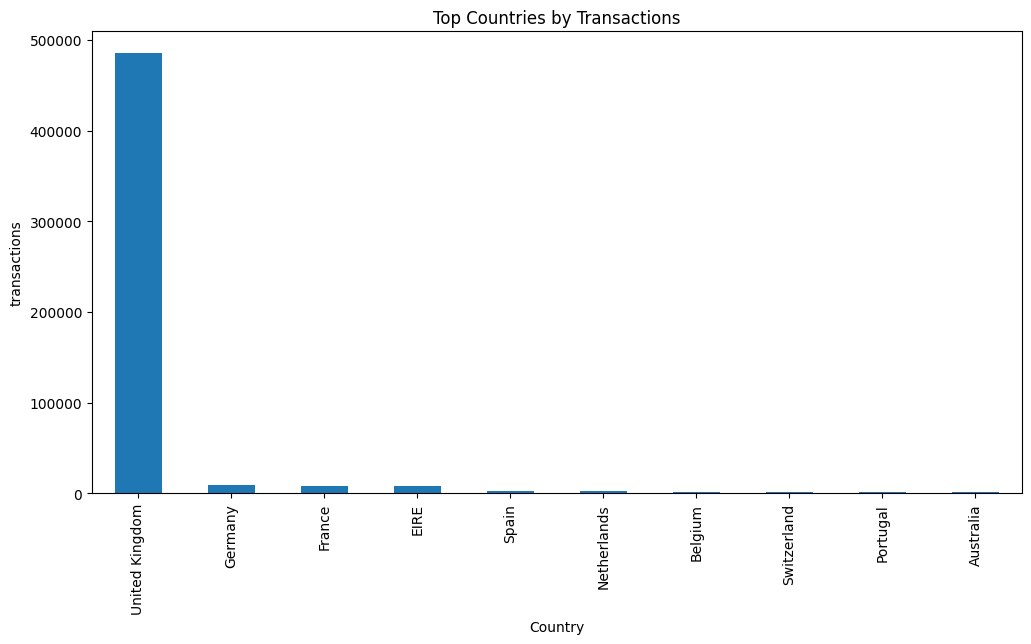

In [16]:
country_sales = df.groupby('Country')['InvoiceNo'].count().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
country_sales.head(10).plot(kind='bar')
plt.title("Top Countries by Transactions")
plt.ylabel("transactions")
plt.show()



## Top Selling Products ##

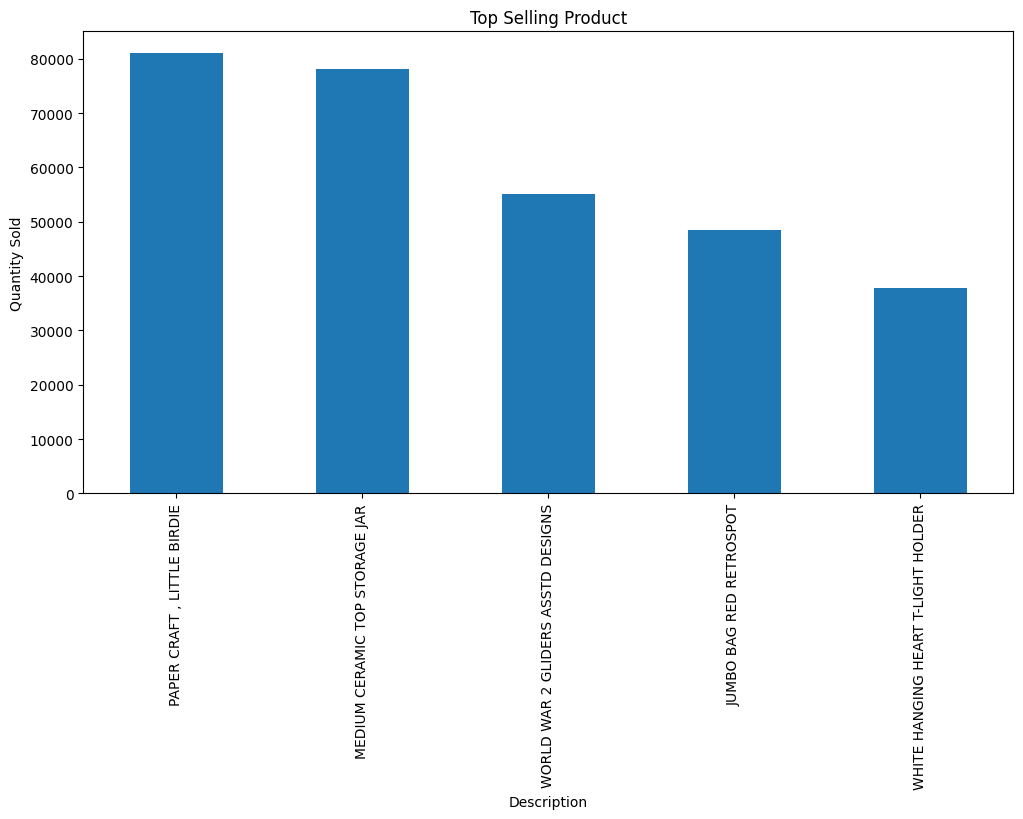

In [17]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head()

plt.figure(figsize=(12, 6))
top_products.plot(kind='bar')
plt.title("Top Selling Product")
plt.ylabel("Quantity Sold")
plt.show()

## Monthly Sales Trend ##

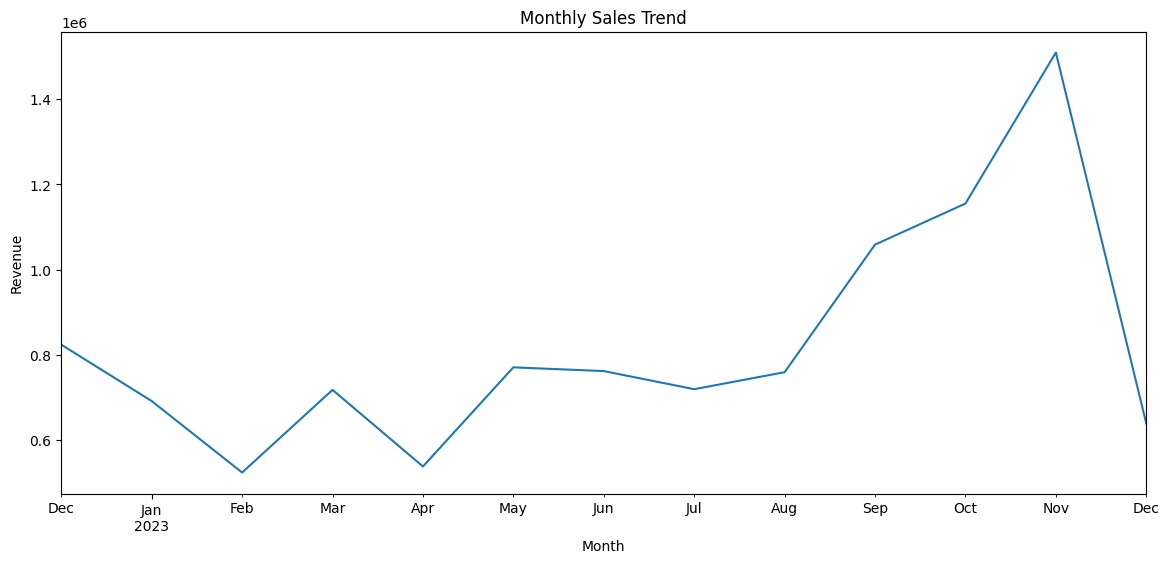

In [18]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')

monthly_sales = df.groupby('Month')['TotalAmount'].sum()

plt.figure(figsize=(14,6))
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.ylabel("Revenue")
plt.show()

## Transaction Value Distribution ##

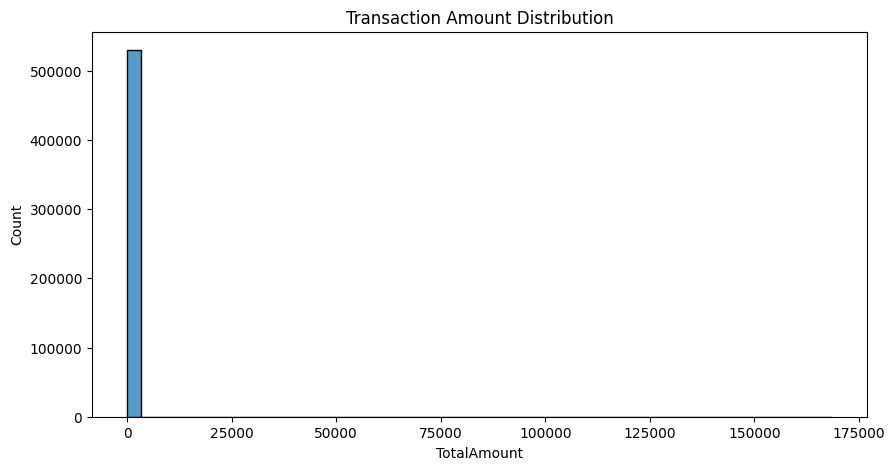

In [19]:
plt.figure(figsize=(10,5))

sns.histplot(df['TotalAmount'], bins=50)

plt.title("Transaction Amount Distribution")
plt.show()

## Create RFM Table ##

In [20]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})
rfm.columns = ['Recency', 'Frequency', 'Monetary']


In [21]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


##  Check RFM Distribution ##


<function matplotlib.pyplot.show(close=None, block=None)>

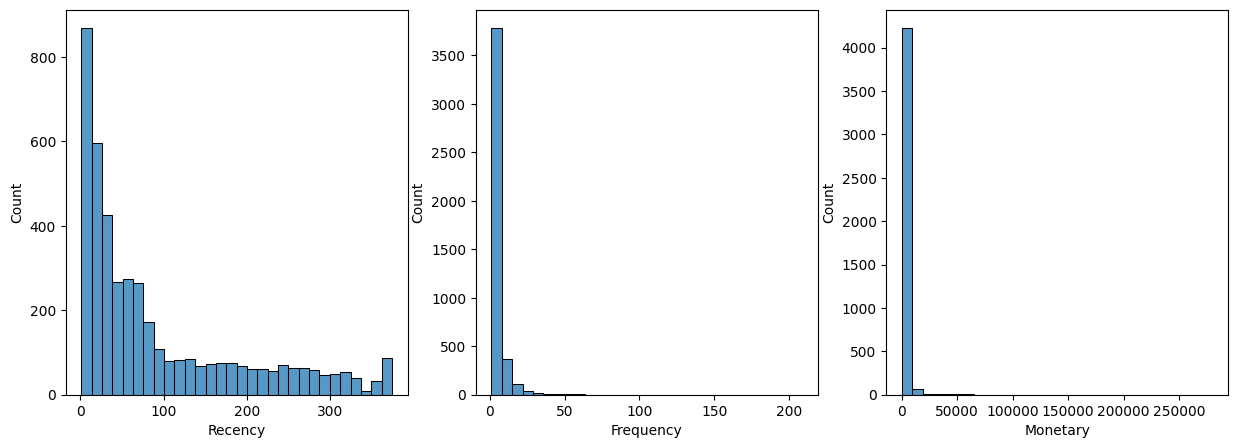

In [22]:
from matplotlib import figure
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sns.histplot(rfm['Recency'],bins=30)
plt.subplot(1,3,2)
sns.histplot(rfm['Frequency'],bins=30)
plt.subplot(1,3,3)
sns.histplot(rfm['Monetary'],bins=30)
plt.show

## Standardize RFM Data ##

In [23]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=rfm.columns,
    index=rfm.index
)


In [24]:
rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334574,-0.425097,8.358668
12347.0,-0.905340,0.354417,0.250966
12348.0,-0.175360,-0.035340,-0.028596
12349.0,-0.735345,-0.425097,-0.033012
12350.0,2.174578,-0.425097,-0.191347


## Elbow Method ##

In [25]:
inertia = []
K = range(2,11)

for k in K:
  kmeans = KMeans(
      n_clusters = k,
      random_state = 42,
      n_init=10
  )

  kmeans.fit(rfm_scaled)
  inertia.append(kmeans.inertia_)


## Plot Elbow Curve ##

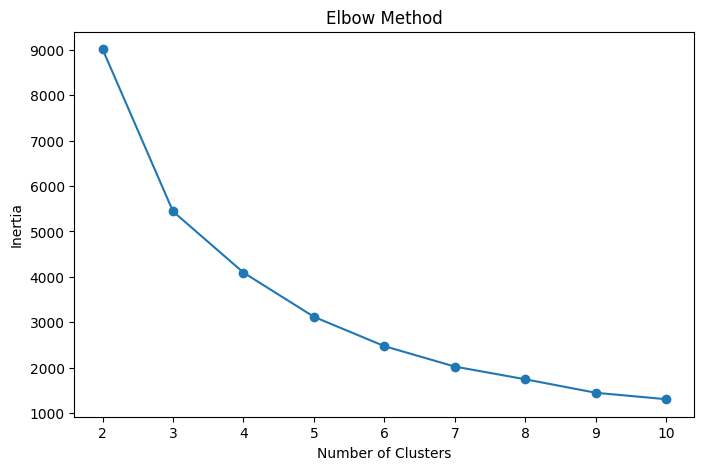

In [26]:
plt.figure(figsize=(8,5))

plt.plot(K, inertia, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

## Silhouette Score ##

In [27]:
for k in range(2,11):

  kmeans = KMeans(
      n_clusters=k,
      random_state=42,
      n_init=10
  )

  labels = kmeans.fit_predict(rfm_scaled)

  score = silhouette_score(
       rfm_scaled,
       labels
   )
  print(f"K={k}, Silhouette Score={score:.4f}")





K=2, Silhouette Score=0.8958
K=3, Silhouette Score=0.5942
K=4, Silhouette Score=0.6162
K=5, Silhouette Score=0.6165
K=6, Silhouette Score=0.5963
K=7, Silhouette Score=0.5165
K=8, Silhouette Score=0.5175
K=9, Silhouette Score=0.4777
K=10, Silhouette Score=0.4271


## Train Final KMeans ##

In [28]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)


In [29]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


## Cluster Summary ##

In [30]:
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2)

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,43.70,3.68,1359.05
1,248.08,1.55,480.62
2,7.38,82.54,127338.31
3,15.50,22.33,12709.09


## Assign Business Labels ##

In [31]:
cluster_labels = {
   0: 'Occasional',
   1: 'At-Risk',
   2: 'High-Value',
   3: 'Regular'
}

rfm['Segment'] = rfm['Cluster'].map(
    cluster_labels
)

In [32]:
rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,1,77183.60,3,Regular
12347.0,2,7,4310.00,0,Occasional
12348.0,75,4,1797.24,0,Occasional
12349.0,19,1,1757.55,0,Occasional
12350.0,310,1,334.40,1,At-Risk


## Segment Counts ##

In [33]:
rfm['Segment'].value_counts()

,count
Segment,
Occasional,3054
At-Risk,1067
Regular,204
High-Value,13


## Segment Distribution Plot ##

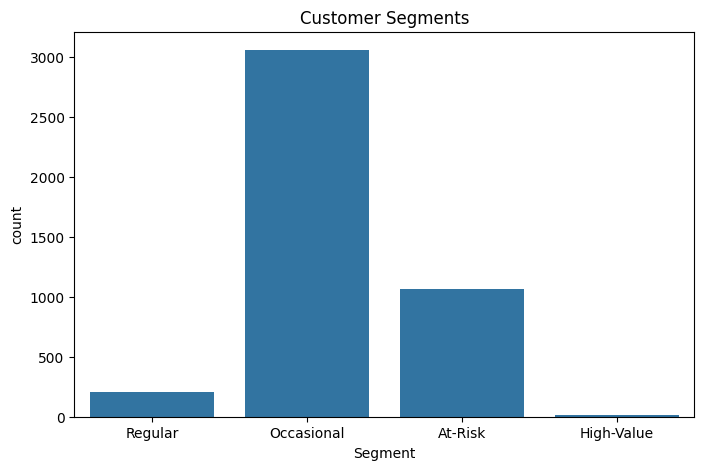

In [34]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=rfm,
    x='Segment'
)

plt.title("Customer Segments")

plt.show()

## Cluster Visualization (2D) ##

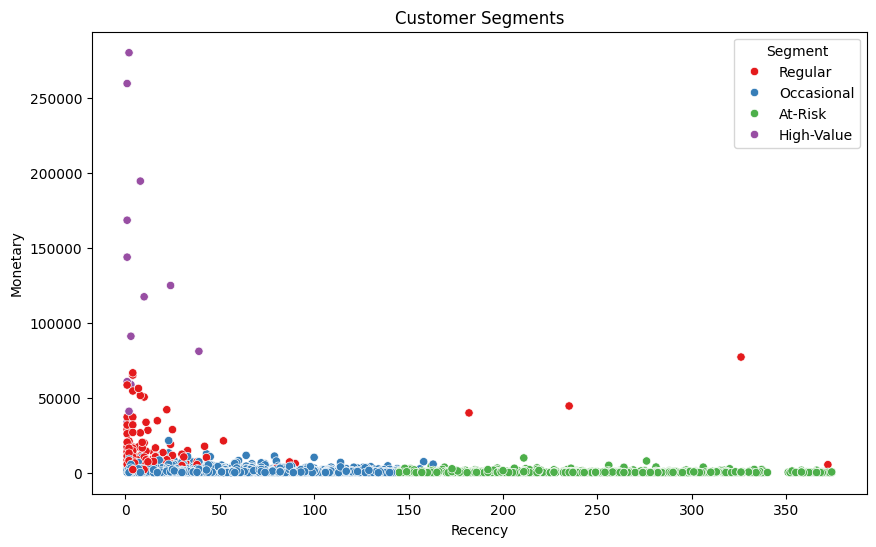

In [35]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Segment',
    palette='Set1'
)

plt.title("Customer Segments")
plt.show()

## 3D Cluster Plot ##

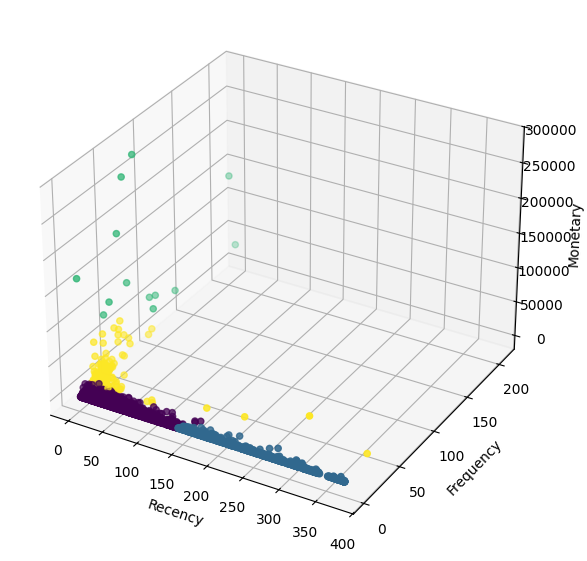

In [36]:
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(
    111,
    projection='3d'
)
scatter = ax.scatter(
    rfm['Recency'],
    rfm['Frequency'],
    rfm['Monetary'],
    c=rfm['Cluster']
)

ax.set_xlabel("Recency")
ax.set_ylabel("Frequency")
ax.set_zlabel("Monetary")

plt.show()

## Save Models ##

In [37]:
import joblib

joblib.dump(
    kmeans,
    'customer_segmentation_model.pkl'
)

joblib.dump(
    scaler,
    'rfm_scaler.pkl'
)

print("Models Saved Successfully")

Models Saved Successfully


## Create Customer-Product Matrix ##

In [38]:
customer_product_matrix = pd.pivot_table(
    df,
    index='CustomerID',
    columns='Description',
    values='Quantity',
    aggfunc='sum',
    fill_value=0
)

customer_product_matrix.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
CustomerID,,,,,,,,,,,,,,,,,,,,,
12346.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12347.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12348.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12349.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12350.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Transpose Matrix ##


In [39]:
product_matrix = customer_product_matrix.T

product_matrix.head()


CustomerID,12346.0,12347.0,12348.0,12349.0,12350.0,12352.0,12353.0,12354.0,12355.0,12356.0,...,18273.0,18274.0,18276.0,18277.0,18278.0,18280.0,18281.0,18282.0,18283.0,18287.0
Description,,,,,,,,,,,,,,,,,,,,,
4 PURPLE FLOCK DINNER CANDLES,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
50'S CHRISTMAS GIFT BAG LARGE,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
DOLLY GIRL BEAKER,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
I LOVE LONDON MINI BACKPACK,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
I LOVE LONDON MINI RUCKSACK,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Calculate Cosine Similarity ##

In [40]:
product_similarity = cosine_similarity(product_matrix)
product_similarity.shape

(3877, 3877)

## Create Similarity DataFrame ##

In [41]:
similarity_df = pd.DataFrame(
    product_similarity,
    index=product_matrix.index,
    columns=product_matrix.index
)
similarity_df.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
Description,,,,,,,,,,,,,,,,,,,,,
4 PURPLE FLOCK DINNER CANDLES,1.000000,0.000000,0.000021,0.000227,0.000000,0.000000,0.020155,0.000000,0.000262,0.063396,...,0.0,0.001368,0.015886,0.001767,0.0,0.002846,0.0,0.013128,0.000000,0.002594
50'S CHRISTMAS GIFT BAG LARGE,0.000000,1.000000,0.003533,0.004001,0.000000,0.020034,0.027433,0.900849,0.119031,0.013380,...,0.0,0.001718,0.015572,0.018032,0.0,0.015710,0.0,0.011238,0.000000,0.029793
DOLLY GIRL BEAKER,0.000021,0.003533,1.000000,0.870851,0.980561,0.006296,0.005302,0.003034,0.001765,0.411331,...,0.0,0.000043,0.002869,0.344923,0.0,0.525860,0.0,0.822946,0.000097,0.006665
I LOVE LONDON MINI BACKPACK,0.000227,0.004001,0.870851,1.000000,0.883883,0.019879,0.004904,0.004043,0.008270,0.382056,...,0.0,0.001409,0.004197,0.310017,0.0,0.471717,0.0,0.749210,0.000000,0.010393
I LOVE LONDON MINI RUCKSACK,0.000000,0.000000,0.980561,0.883883,1.000000,0.000000,0.000000,0.000000,0.000000,0.410578,...,0.0,0.000000,0.000000,0.347021,0.0,0.530836,0.0,0.837170,0.000000,0.000000


## Recommendation Function ##

In [42]:
def recommend_products(product_name, top_n=5):

    if product_name not in similarity_df.index:
      return ["Product not found"]

    similar_scores = similarity_df[product_name]

    recommendations = (
        similar_scores
        .sort_values(ascending=False)
        .drop(product_name)
        .head(top_n)
    )

    return recommendations.index.tolist()

## Test Recommendation System ##

In [43]:
recommend_products("ASSORTED COLOUR BIRD ORNAMENT")

['IVORY DINER WALL CLOCK',
 'JINGLE BELL HEART ANTIQUE SILVER',
 'GIRAFFE WOODEN RULER',
 'PAINT YOUR OWN CANVAS SET',
 'WHITE SKULL HOT WATER BOTTLE ']

## Find Available Products ##

In [44]:
print(product_matrix.index[:50])

Index([' 4 PURPLE FLOCK DINNER CANDLES', ' 50'S CHRISTMAS GIFT BAG LARGE',
       ' DOLLY GIRL BEAKER', ' I LOVE LONDON MINI BACKPACK',
       ' I LOVE LONDON MINI RUCKSACK', ' NINE DRAWER OFFICE TIDY',
       ' OVAL WALL MIRROR DIAMANTE ', ' RED SPOT GIFT BAG LARGE',
       ' SET 2 TEA TOWELS I LOVE LONDON ', ' SPACEBOY BABY GIFT SET',
       ' TOADSTOOL BEDSIDE LIGHT ', ' TRELLIS COAT RACK',
       '10 COLOUR SPACEBOY PEN', '12 COLOURED PARTY BALLOONS',
       '12 DAISY PEGS IN WOOD BOX', '12 EGG HOUSE PAINTED WOOD',
       '12 HANGING EGGS HAND PAINTED', '12 IVORY ROSE PEG PLACE SETTINGS',
       '12 MESSAGE CARDS WITH ENVELOPES', '12 PENCIL SMALL TUBE WOODLAND',
       '12 PENCILS SMALL TUBE RED RETROSPOT', '12 PENCILS SMALL TUBE SKULL',
       '12 PENCILS TALL TUBE POSY', '12 PENCILS TALL TUBE RED RETROSPOT',
       '12 PENCILS TALL TUBE SKULLS', '12 PENCILS TALL TUBE WOODLAND',
       '12 PINK HEN+CHICKS IN BASKET', '12 PINK ROSE PEG PLACE SETTINGS',
       '12 RED ROSE PEG PLACE

In [45]:
product_matrix.index.tolist()[:50]

[' 4 PURPLE FLOCK DINNER CANDLES',
 " 50'S CHRISTMAS GIFT BAG LARGE",
 ' DOLLY GIRL BEAKER',
 ' I LOVE LONDON MINI BACKPACK',
 ' I LOVE LONDON MINI RUCKSACK',
 ' NINE DRAWER OFFICE TIDY',
 ' OVAL WALL MIRROR DIAMANTE ',
 ' RED SPOT GIFT BAG LARGE',
 ' SET 2 TEA TOWELS I LOVE LONDON ',
 ' SPACEBOY BABY GIFT SET',
 ' TOADSTOOL BEDSIDE LIGHT ',
 ' TRELLIS COAT RACK',
 '10 COLOUR SPACEBOY PEN',
 '12 COLOURED PARTY BALLOONS',
 '12 DAISY PEGS IN WOOD BOX',
 '12 EGG HOUSE PAINTED WOOD',
 '12 HANGING EGGS HAND PAINTED',
 '12 IVORY ROSE PEG PLACE SETTINGS',
 '12 MESSAGE CARDS WITH ENVELOPES',
 '12 PENCIL SMALL TUBE WOODLAND',
 '12 PENCILS SMALL TUBE RED RETROSPOT',
 '12 PENCILS SMALL TUBE SKULL',
 '12 PENCILS TALL TUBE POSY',
 '12 PENCILS TALL TUBE RED RETROSPOT',
 '12 PENCILS TALL TUBE SKULLS',
 '12 PENCILS TALL TUBE WOODLAND',
 '12 PINK HEN+CHICKS IN BASKET',
 '12 PINK ROSE PEG PLACE SETTINGS',
 '12 RED ROSE PEG PLACE SETTINGS',
 '15 PINK FLUFFY CHICKS IN BOX',
 '15CM CHRISTMAS GLASS BALL 20 

## Similarity Heatmap ##

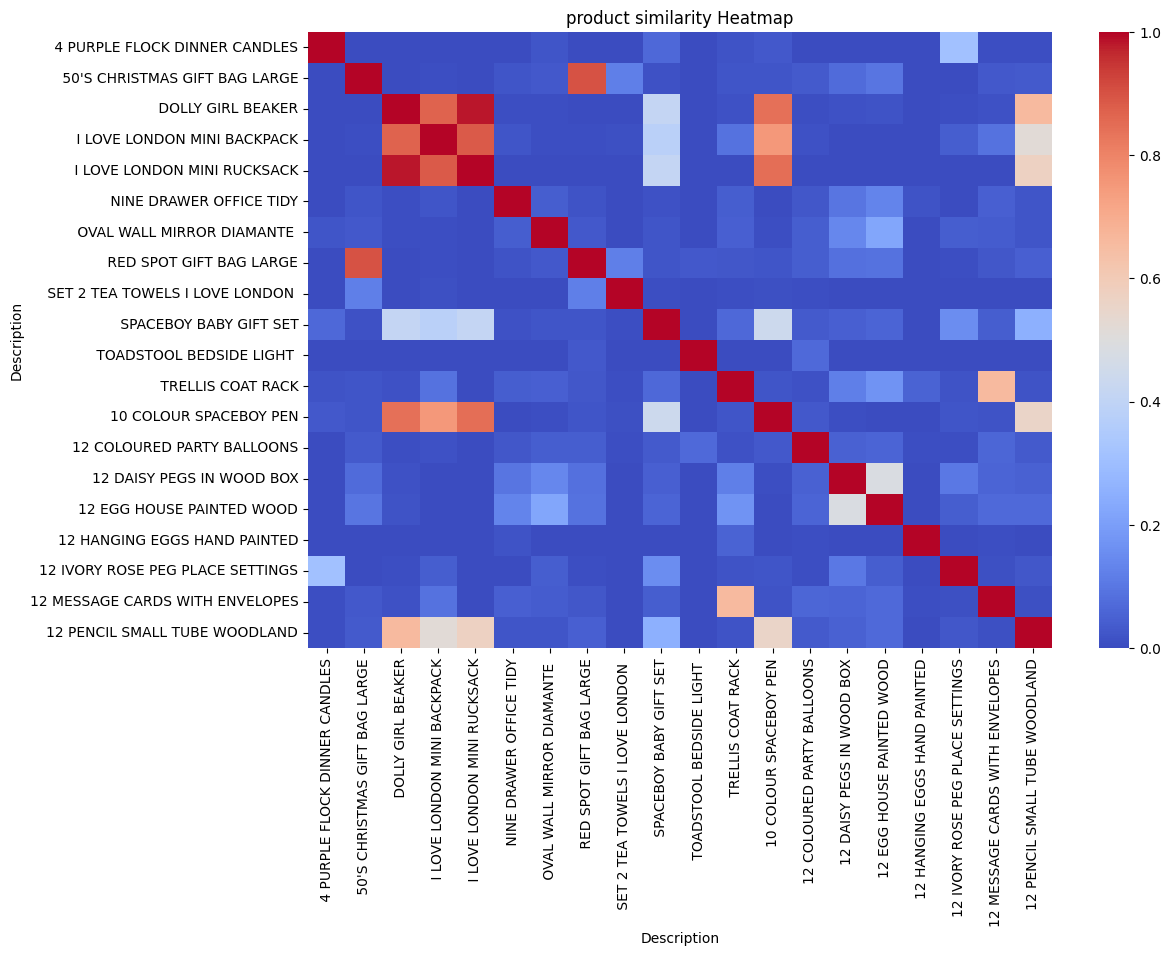

In [46]:
top_products = similarity_df.iloc[:20, :20]
plt.figure(figsize=(12,8))

sns.heatmap(
    top_products,
    cmap='coolwarm'
)

plt.title("product similarity Heatmap")

plt.show()

## Interactive Testing ##

In [47]:
product = input("Enter Product Name:")
recommend_products(product)

Enter Product Name:sjdbiysd


['Product not found']

## Save Recommendation Model ##

In [48]:
import joblib

joblib.dump(
    similarity_df,
    'product_similarity.pkl'
)

print("Recommendation Model Saved")

Recommendation Model Saved


In [49]:
import os

os.listdir()

['.config',
 'product_similarity.pkl',
 'drive',
 'customer_segmentation_model.pkl',
 'rfm_scaler.pkl',
 'sample_data']

In [50]:
from google.colab import files

files.download('customer_segmentation_model.pkl')
files.download('rfm_scaler.pkl')
files.download('product_similarity.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusion : ##
This project successfully analyzed customer purchasing behavior using RFM analysis and segmented customers into meaningful groups using KMeans Clustering. An item-based collaborative filtering recommendation system was developed to provide personalized product suggestions. The Streamlit application enables real-time customer segmentation and product recommendations, helping businesses improve customer engagement, targeted marketing, and decision-making.